<a href="https://colab.research.google.com/github/amann45/AI_Labworks/blob/main/Lab2/Linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Assignment: Linear Regression [Aman Kumar Ray: ACE080BCT010]

## Task: Simple Linear Regression (Single Feature)
Problem Statement: Build a simple linear regression model using only one input feature to predict housing prices.

* Input Feature: YearsExperience
* Label: Salary


1️⃣ Data Retrieval and Collection

In [1]:
# install dependencies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('Salary_Data.csv')
df.head()

,YearsExperience,Salary
0,1.1,39343
1,1.3,46205
2,1.5,37731
3,2.0,43525
4,2.2,39891


In [3]:
#checking all the column present in the dataset
df.columns

Index(['YearsExperience', 'Salary'], dtype='object')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  30 non-null     float64
 1   Salary           30 non-null     int64  
dtypes: float64(1), int64(1)
memory usage: 612.0 bytes


In [5]:
print(df.shape)

(30, 2)


In [6]:
df.describe()

,YearsExperience,Salary
count,30.000000,30.000000
mean,5.313333,76003.000000
std,2.837888,27414.429785
min,1.100000,37731.000000
25%,3.200000,56720.750000
50%,4.700000,65237.000000
75%,7.700000,100544.750000
max,10.500000,122391.000000


2️⃣ Data Cleaning

In [7]:
#identifying empty cells
df.isnull().sum()

,0
YearsExperience,0
Salary,0


##### Observation: There is no missing values
##### Missing value treatement:
Since there is no missing values in the selected feature(YearsExperience), no treatement is required. if there were missing values present, we would have handle using:

In [8]:
df['YearsExperience'].fillna(df['YearsExperience'].mean(), inplace=True)

In [9]:
df.dtypes

,0
YearsExperience,float64
Salary,int64


3️⃣ Feature Design

In [10]:
X = df[['YearsExperience']]
y = df['Salary']

##### This features was choosen because:
* YearsExperiences impacts the Salary
* less YearsExperience may get higher Salary & vice versa
* suitable for the single feature linear regression

4️⃣Algorithm Selection: Linear Regression

Linear Regression is selected for this task because our goal is to predict a *numerical value* which is a *Salary*.

In this task we are using *one input feature* i.e YearsExperience to make prediction. This make the problem a *simple Linear Regression* problem.

Linear regression tries to find a straight-line relationship between the input feature and the output value. it helps to understand how changes in the years of experiences affect the Salary. Therefore it is suitable and effective algorithm for predicting Salary based on YearsExperience.


5️⃣ Loss Function Selection: Mean Squared Error (MSE)

Mean Squared Error (MSE) is used as the loss function for this linear regression model. it measures the average of the squared differences between the actual values and the predicted values.

Mathematically, it is defined as:

MSE = (1/n) Σ (y_actual − y_predicted)²

Why MSE is used:

* Squaring the errors ensures all values are positive
* Larger errors are penalized more heavily
* It provides a clear measure of prediction

A lower MSE value indicates that the model’s predictions are closer to the actual salary, meaning the model performs better.

6️⃣ Model Learning (Training)

In [11]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [12]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

##### Learning Process
During training, the Linear Regression algorithm analyzes the training data and learns the best-fit straight line that minimizes the prediction error between the actual salary values and the predicted salary values. This is achieved using the Least Squares Method, which minimizes the sum of squared residuals (differences between actual and predicted values).

but, as per the assignment we used the MSE and concluded the process.

7️⃣ Model Evaluation

In [13]:
from sklearn.metrics import mean_squared_error, r2_score

y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R² Score:", r2)

Mean Squared Error: 49830096.85590839
R² Score: 0.9024461774180497


In [14]:
rmse = np.sqrt(mse)
print("RMSE:", rmse)

RMSE: 7059.04362190151


##### Mean Squared Error (MSE): The Mean Squared Error (MSE) was 49,830,096.86, corresponding to an RMSE of approximately 7,059. This suggests that the model predicts salaries with an average error of about 7,059 units, demonstrating good predictive performance.

##### R2 Score: The Linear Regression model achieved an R² score of 0.9024, indicating that approximately 90.24% of the variation in salary can be explained by years of experience.

In [15]:
print("Intercept:",model.intercept_)
print("Coefficient:",model.coef_)

Intercept: 25321.583011776813
Coefficient: [9423.81532303]


📈 Model Interpretation
* Coefficient (Slope): 9423.81
* Intercept: 25321.6

1. What does the coefficient represent?

* The coefficient (slope) indicates how much the predicted salary changes for each additional year of experience.

* In this model, for every additional year of experience, the salary is expected to increase by approximately 9,423.81 units, assuming all other factors remain constant.

2. What does the intercept mean?

* The intercept represents the predicted salary when the years of experience is 0. In this model, a person with 0 years of experience is predicted to have a salary of approximately 25321.6 units.

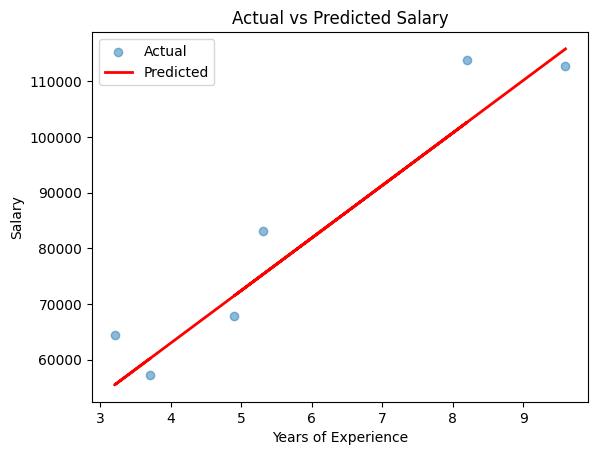

In [16]:
plt.scatter(X_test, y_test, label="Actual", alpha=0.5)
plt.plot(X_test, y_pred, color='red', label="Predicted", linewidth=2)
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.title("Actual vs Predicted Salary")
plt.legend()
plt.show()

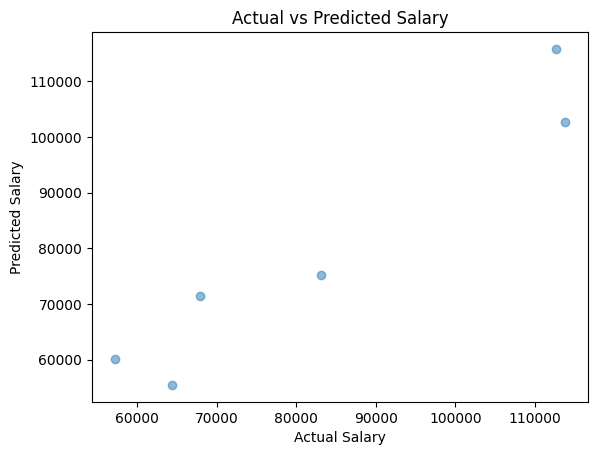

In [17]:
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title("Actual vs Predicted Salary")
plt.show()

#### Assumptions of Linear Regression
1. Linearity
* There should be a linear relationship between the input feature and the target variable. In this case, YearsExperience should be linearly related to Salary.

2. Independence
* The observations must be independent of each other.
Each data point should not affect another.

3. Homoscedasticity
* The error (residual) values should have constant variance.
Errors should not increase or decrease with the input feature.

4. Normality of Residuals
* The residuals (difference between actual and predicted) should be normally distributed.

5. No Multicollinearity
* In simple linear regression (one feature), this is automatically satisfied because only one feature is used

## Discussion
The Linear Regression model was trained to predict employee salary based on years of experience. The model showed a strong relationship between the independent variable (Years of Experience) and the dependent variable (Salary). The obtained R² score of 0.9024 indicates that approximately 90.24% of the variation in salary can be explained by years of experience alone. This suggests that years of experience is a significant factor in determining salary.

The Mean Squared Error (MSE) was 49,830,096.86, which corresponds to an RMSE of approximately 7,059. This indicates that the model's salary predictions differ from the actual salaries by about 7,059 units on average. The regression coefficient showed a positive relationship between experience and salary, meaning that salary tends to increase as years of experience increase.

## Conclusion
In this lab we successfully applied Linear Regression to predict salaries based on years of experience. The model achieved an R² score of 0.9024, demonstrating strong predictive performance and a strong linear relationship between experience and salary. The results indicate that years of experience is an important predictor of salary.

Overall, the model provides reliable salary estimates and demonstrates the effectiveness of Linear Regression for solving simple regression problems. Future work could involve incorporating additional features and testing more advanced machine learning algorithms to further improve prediction accuracy.